# Evaluation: main table, turbulence evaluation

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import sys


sys.path.append("..")

os.environ["CUDA_VISIBLE_DEVICES"] = "5"
device = "cuda"

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.gridspec import GridSpec
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

import torch
import warnings
import pickle

warnings.filterwarnings("ignore", message="__array_wrap__ must accept context*")

from neugk.dataset import CycloneAEDataset

from neugk.pinc.autoencoders.ae_utils import load_autoencoder

In [ ]:
BASE_PATH = "/system/user/publicwork/galletti/huggingface"

In [ ]:
# AE
int_ae = f"{BASE_PATH}/autoencoders/ae/best.pth"
int_ae, _, int_ae_cfg = load_autoencoder(int_ae, device=device, load_peft=True)
int_ae.eval()

In [ ]:
int_ae = "/system/user/publicwork/galletti/best.pth"
int_ae, _, int_ae_cfg = load_autoencoder(int_ae, device=device, load_peft=True)
int_ae.eval()

print(f"AE parameters: {sum(p.numel() for p in int_ae.parameters()) / 1e6:.1f}M")

In [107]:
TRAJECTORIES = ["iteration_13"] + [f"iteration_{i}" for i in range(100, 150)]

DATAS = {}

stats = {
    "df": pickle.load(
        open("/system/user/publicwork/galletti/tmp_norm_stats_mu.pkl", "rb")
    ),
    "phi": pickle.load(
        open("/system/user/publicwork/galletti/phi_tmp_norm_stats_mu.pkl", "rb")
    ),
    "flux": pickle.load(
        open("/system/user/publicwork/galletti/flux_tmp_norm_stats_mu.pkl", "rb")
    ),
}
train_norm_stats = {
    k: {
        "full": {
            "mean": stats[k].mean.astype(np.float32),
            "std": (stats[k].var ** 0.5).astype(np.float32),
        }
    }
    for k in stats
}

for t in TRAJECTORIES:
    data = CycloneAEDataset(
        path=f"/local00/bioinf/gyrokinetics/preprocessed",
        split="train",
        input_fields=["df", "phi", "flux"],
        random_seed=int_ae_cfg.seed,
        normalization=int_ae_cfg.dataset.normalization,
        normalization_scope=int_ae_cfg.dataset.normalization_scope,
        normalization_stats=train_norm_stats,
        trajectories=[f"{t}.h5"],
        separate_zf=int_ae_cfg.dataset.separate_zf,
        decouple_mu=int_ae_cfg.model.decouple_mu,
        real_potens=True,
        conditions=["itg", "dg", "s_hat", "q"],
        offset=150,
    )
    if data[0].avg_flux > 10:
        DATAS[t] = data
len(DATAS)

51

In [ ]:
BATCH_SIZE = 64
STEP = 5

AE_LATENTS = {}
COND_TO_TRAJ = {}

int_ae.to(device).eval()
int_vqvae.to(device).eval()

with torch.no_grad():
    for t in DATAS:
        first_cond = DATAS[t][0].conditioning
        key = tuple(c.item() for c in first_cond)

        AE_LATENTS[key] = []
        COND_TO_TRAJ[key] = t
        indices = list(range(0, len(DATAS[t]) - 1, STEP))

        for i in range(0, len(indices), BATCH_SIZE):
            batch_indices = indices[i : i + BATCH_SIZE]
            batch_samples = [DATAS[t][idx] for idx in batch_indices]
            if not batch_samples:
                continue

            df_batch = torch.stack([s.df for s in batch_samples]).to(device)
            flux_batch = [s.flux.item() for s in batch_samples]
            cond_batch = torch.stack([s.conditioning for s in batch_samples]).to(device)

            ae_out_batch = int_ae.encode(df_batch, condition=cond_batch)[0]
            ae_out_batch = ae_out_batch.cpu().numpy()

            for j in range(len(batch_samples)):
                AE_LATENTS[key].append((ae_out_batch[j : j + 1], flux_batch[j]))

Explained variance: 59.33%


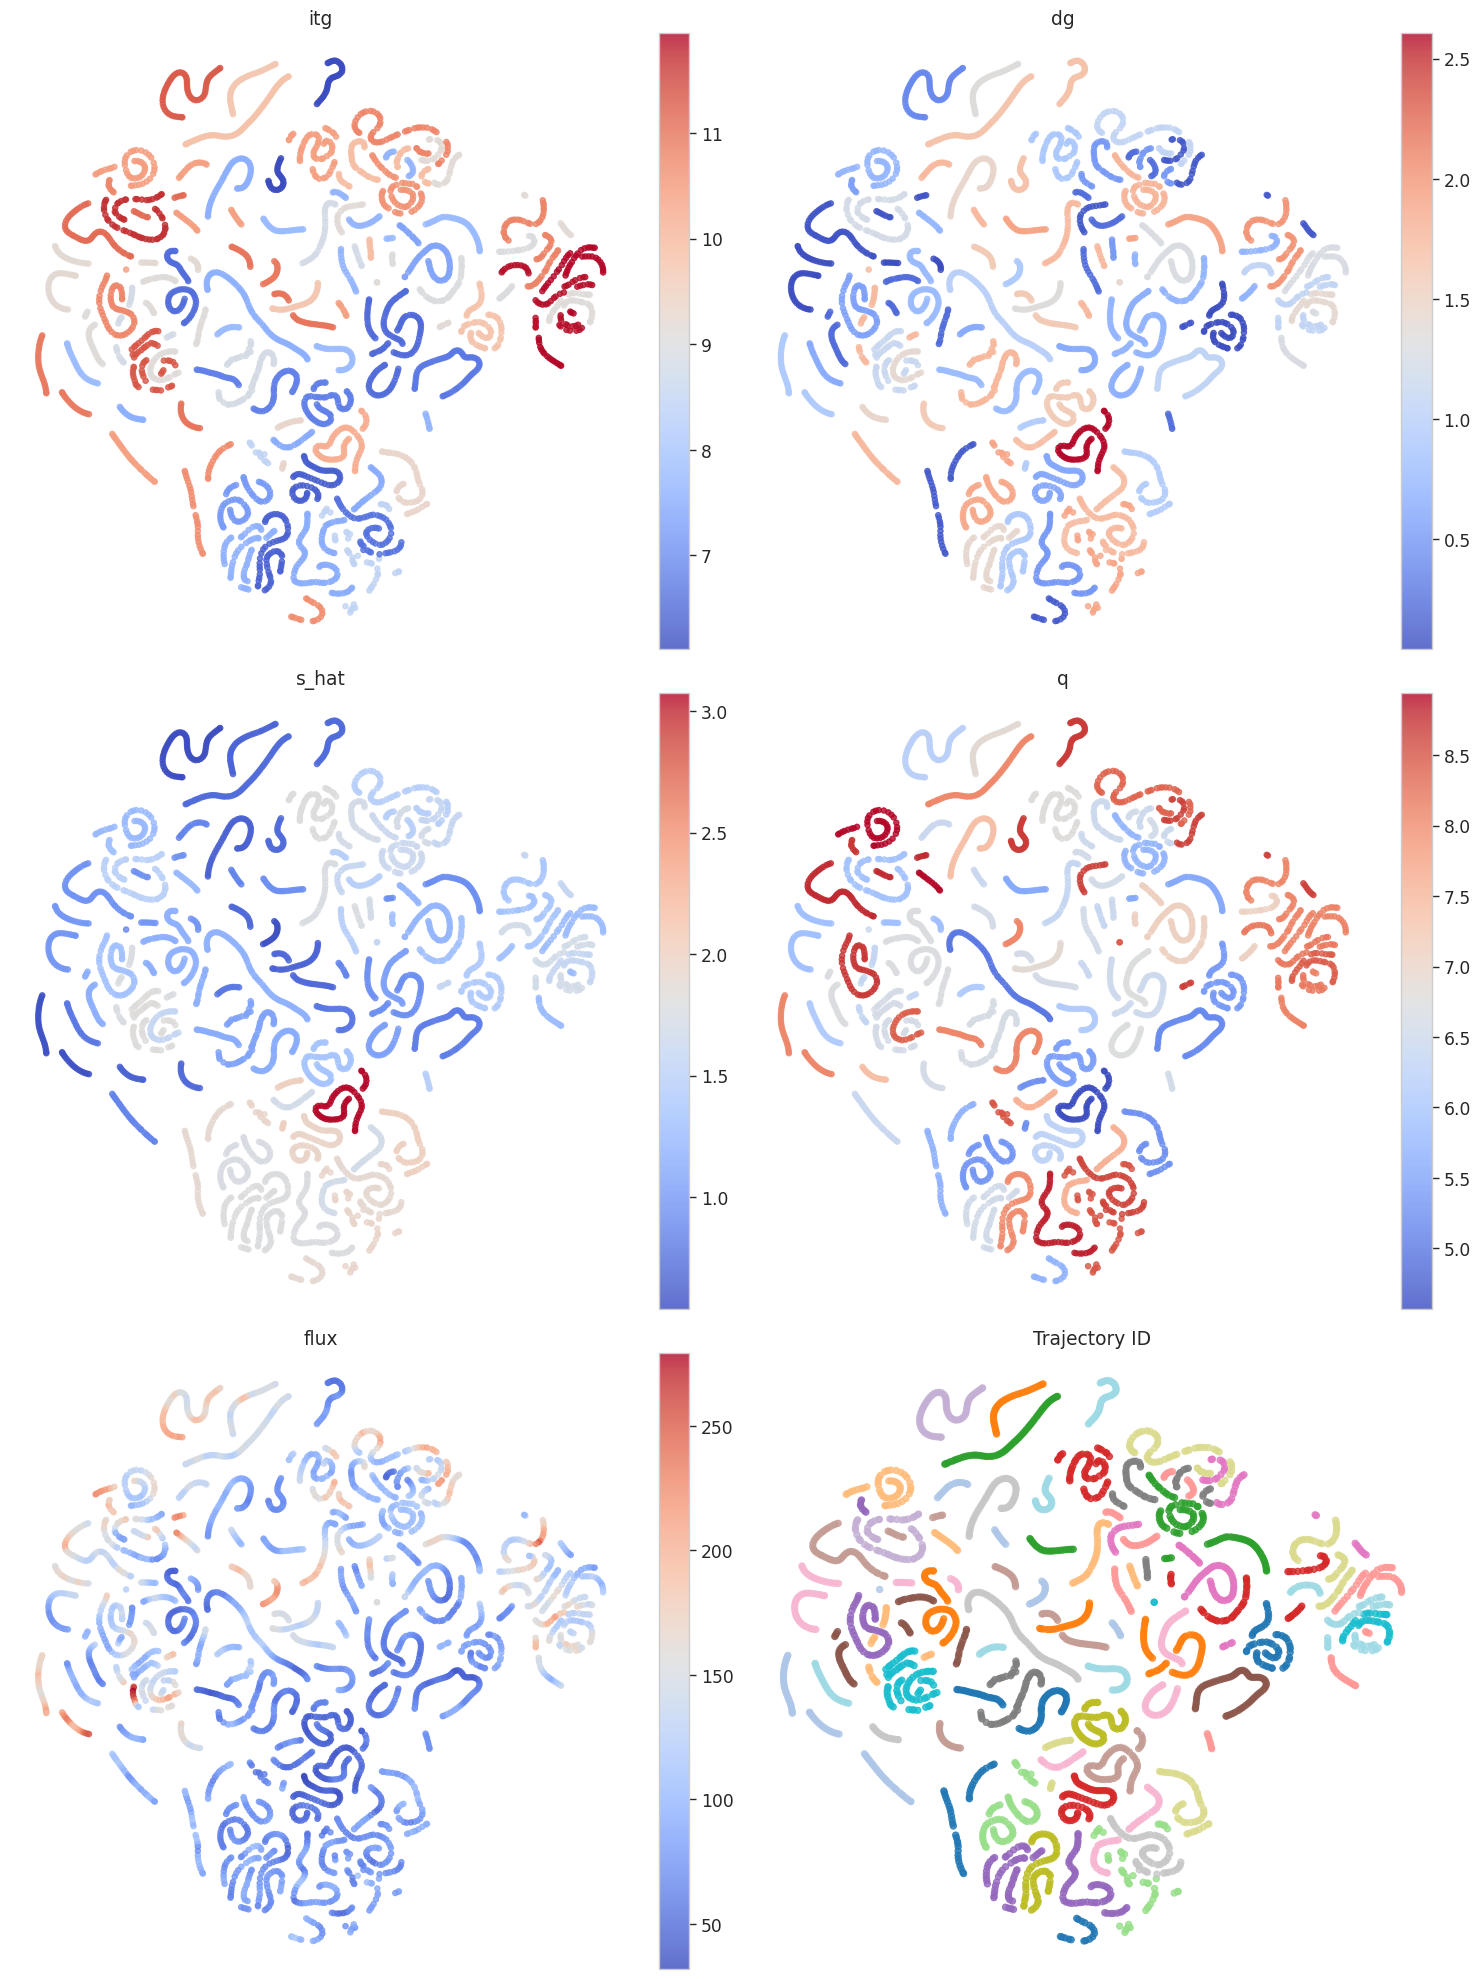

In [121]:
X_list = []
conditions_list = []
traj_list = []

for key_conditions, latents_list in AE_LATENTS.items():
    t_name = COND_TO_TRAJ[key_conditions]
    for latent, flux in latents_list:
        flat_latent = np.array(latent).flatten()
        X_list.append(flat_latent)
        conditions_list.append(key_conditions + (flux,))
        traj_list.append(t_name)

X = np.array(X_list)
conditions = np.array(conditions_list)
traj_names = np.array(traj_list)

scaler = StandardScaler()
X_norm = scaler.fit_transform(X)

pca = PCA(n_components=128)
X_pca = pca.fit_transform(X_norm)
print(f"Explained variance: {np.sum(pca.explained_variance_ratio_):.2%}")

tsne = TSNE(
    n_components=2, perplexity=30, random_state=42, init="pca", learning_rate="auto"
)
X_embedded = tsne.fit_transform(X)

fig = plt.figure(figsize=(15, 20))

gs = GridSpec(3, 2, figure=fig, height_ratios=[1, 1, 1])

cond_names = ["itg", "dg", "s_hat", "q", "flux"]

axes = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[1, 0]),
    fig.add_subplot(gs[1, 1]),
    fig.add_subplot(gs[2, 0]),
]

for i in range(5):
    ax = axes[i]
    c_values = conditions[:, i]
    scatter = ax.scatter(
        X_embedded[:, 0], X_embedded[:, 1], c=c_values, cmap="coolwarm", s=15, alpha=0.8
    )
    ax.set_title(cond_names[i])
    ax.axis("off")
    plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.04)

ax_traj = fig.add_subplot(gs[2, 1])

unique_trajs = np.unique(traj_names)
traj_to_id = {name: i for i, name in enumerate(unique_trajs)}
c_ids = np.array([traj_to_id[t] for t in traj_names])

cmap = plt.get_cmap("tab20")
scatter_traj = ax_traj.scatter(
    X_embedded[:, 0], X_embedded[:, 1], c=c_ids, cmap=cmap, s=20, alpha=0.8
)

ax_traj.set_title("Trajectory ID")
ax_traj.axis("off")

handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=cmap(i / len(unique_trajs)),
        markersize=10,
    )
    for i in range(len(unique_trajs))
]
# ax_traj.legend(
#     handles,
#     unique_trajs,
#     title="Trajectories",
#     loc="center left",
#     bbox_to_anchor=(1, 0.5),
# )

plt.tight_layout()

Global Silhouette Score: -0.0327


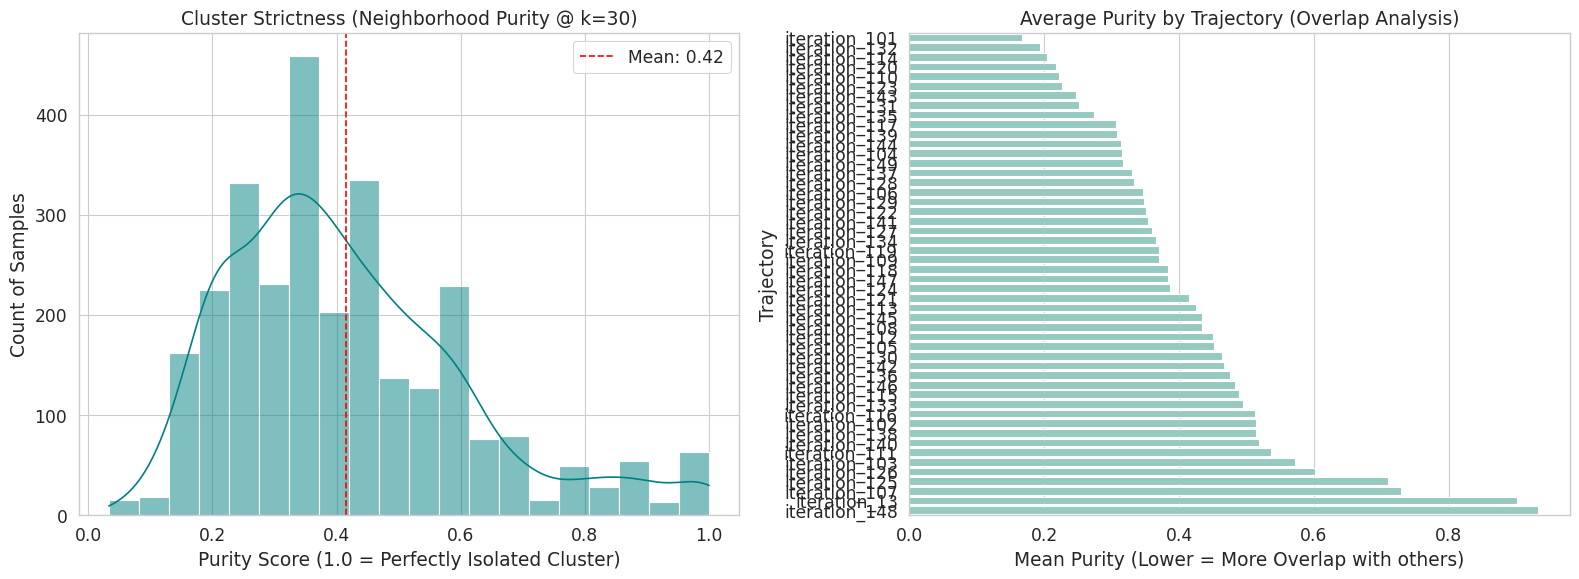

In [116]:
labels = traj_names
unique_labels = np.unique(labels)

sil_avg = silhouette_score(X_pca, labels)
print(f"Global Silhouette Score: {sil_avg:.4f}")

k = 30
nbrs = NearestNeighbors(n_neighbors=k + 1).fit(X_pca)
distances, indices = nbrs.kneighbors(X_pca)

purity_scores = []
for i, neighbor_indices in enumerate(indices):
    neighbor_indices = neighbor_indices[1:]

    neighbor_labels = labels[neighbor_indices]

    current_label = labels[i]
    match_count = np.sum(neighbor_labels == current_label)
    purity = match_count / k
    purity_scores.append(purity)

purity_scores = np.array(purity_scores)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(purity_scores, bins=20, kde=True, ax=ax1, color="teal")
ax1.axvline(
    np.mean(purity_scores),
    color="r",
    linestyle="--",
    label=f"Mean: {np.mean(purity_scores):.2f}",
)
ax1.set_title(f"Cluster Strictness (Neighborhood Purity @ k={k})")
ax1.set_xlabel("Purity Score (1.0 = Perfectly Isolated Cluster)")
ax1.set_ylabel("Count of Samples")
ax1.legend()

df_purity = pd.DataFrame({"Trajectory": labels, "Purity": purity_scores})
avg_purity_per_traj = df_purity.groupby("Trajectory")["Purity"].mean().sort_values()

sns.barplot(x=avg_purity_per_traj.values, y=avg_purity_per_traj.index, ax=ax2)
ax2.set_title("Average Purity by Trajectory (Overlap Analysis)")
ax2.set_xlabel("Mean Purity (Lower = More Overlap with others)")

plt.tight_layout()

In [154]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.base import clone


le = LabelEncoder()
y_classes_enc = le.fit_transform(traj_names.ravel())

indices = np.arange(X.shape[0])
X_train, X_test, idx_train, idx_test = train_test_split(
    X, indices, test_size=0.2, random_state=42
)

y_cond_train = conditions[idx_train]
y_cond_test = conditions[idx_test]

y_class_train = y_classes_enc[idx_train]
y_class_test = y_classes_enc[idx_test]


def get_pipelines(model_type="ridge"):
    if model_type == "ridge":
        est = Ridge(alpha=10.0)
    else:
        est = LogisticRegression(max_iter=1000, C=0.1, solver="lbfgs")

    pipelines = {
        "Raw": Pipeline([("scaler", StandardScaler()), ("model", clone(est))]),
        "PCA": Pipeline(
            [
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=128)),
                ("model", clone(est)),
            ]
        ),
    }
    return pipelines


results = []
cond_names = ["itg", "dg", "s_hat", "q", "flux"]

for i in range(conditions.shape[-1]):
    target_name = cond_names[i]
    y_train_curr = y_cond_train[:, i]
    y_test_curr = y_cond_test[:, i]

    pipes = get_pipelines("ridge")

    for method, pipe in pipes.items():
        pipe.fit(X_train, y_train_curr)
        preds = pipe.predict(X_test)

        results.append(
            {
                "Target": target_name,
                "Task": "Regression",
                "Method": method,
                "Metric 1 (MSE/Acc)": mean_squared_error(y_test_curr, preds),
                "Metric 2 (R2)": r2_score(y_test_curr, preds),
                "Model": pipe,
            }
        )

target_name = "Trajectory"
pipes = get_pipelines("logistic")

for method, pipe in pipes.items():
    pipe.fit(X_train, y_class_train)
    preds = pipe.predict(X_test)

    results.append(
        {
            "Target": target_name,
            "Task": "Classification",
            "Method": method,
            "Metric 1 (MSE/Acc)": accuracy_score(y_class_test, preds),
            "Metric 2 (R2)": None,
            "Model": pipe,
        }
    )

results_df = pd.DataFrame(results)

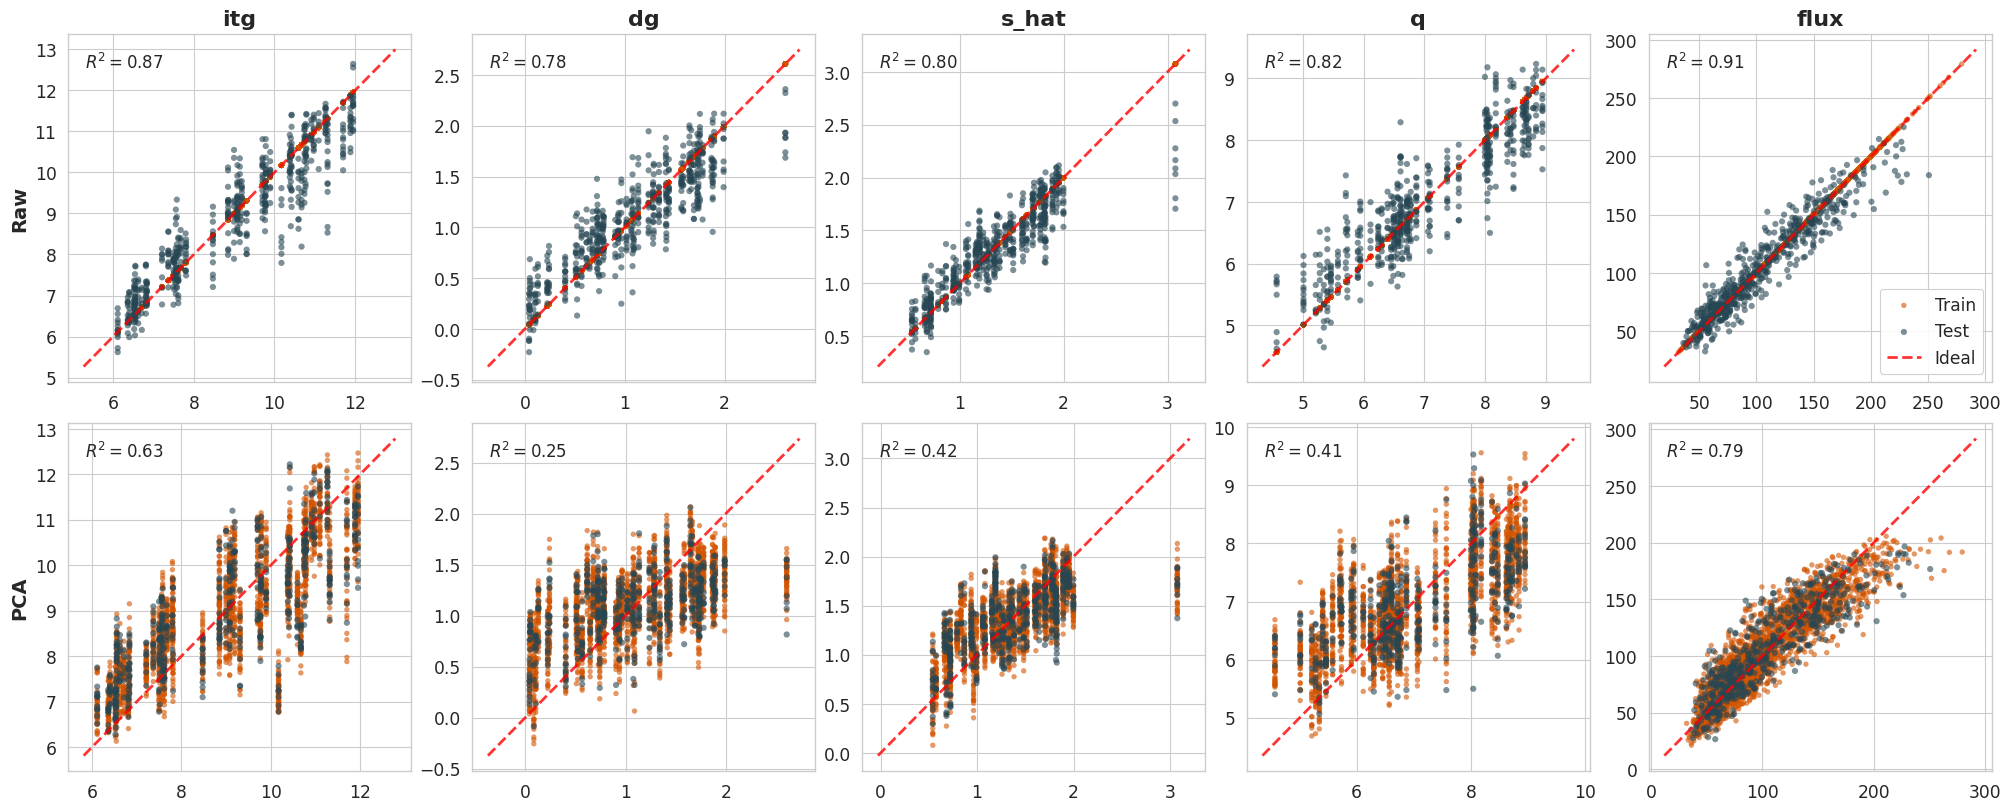

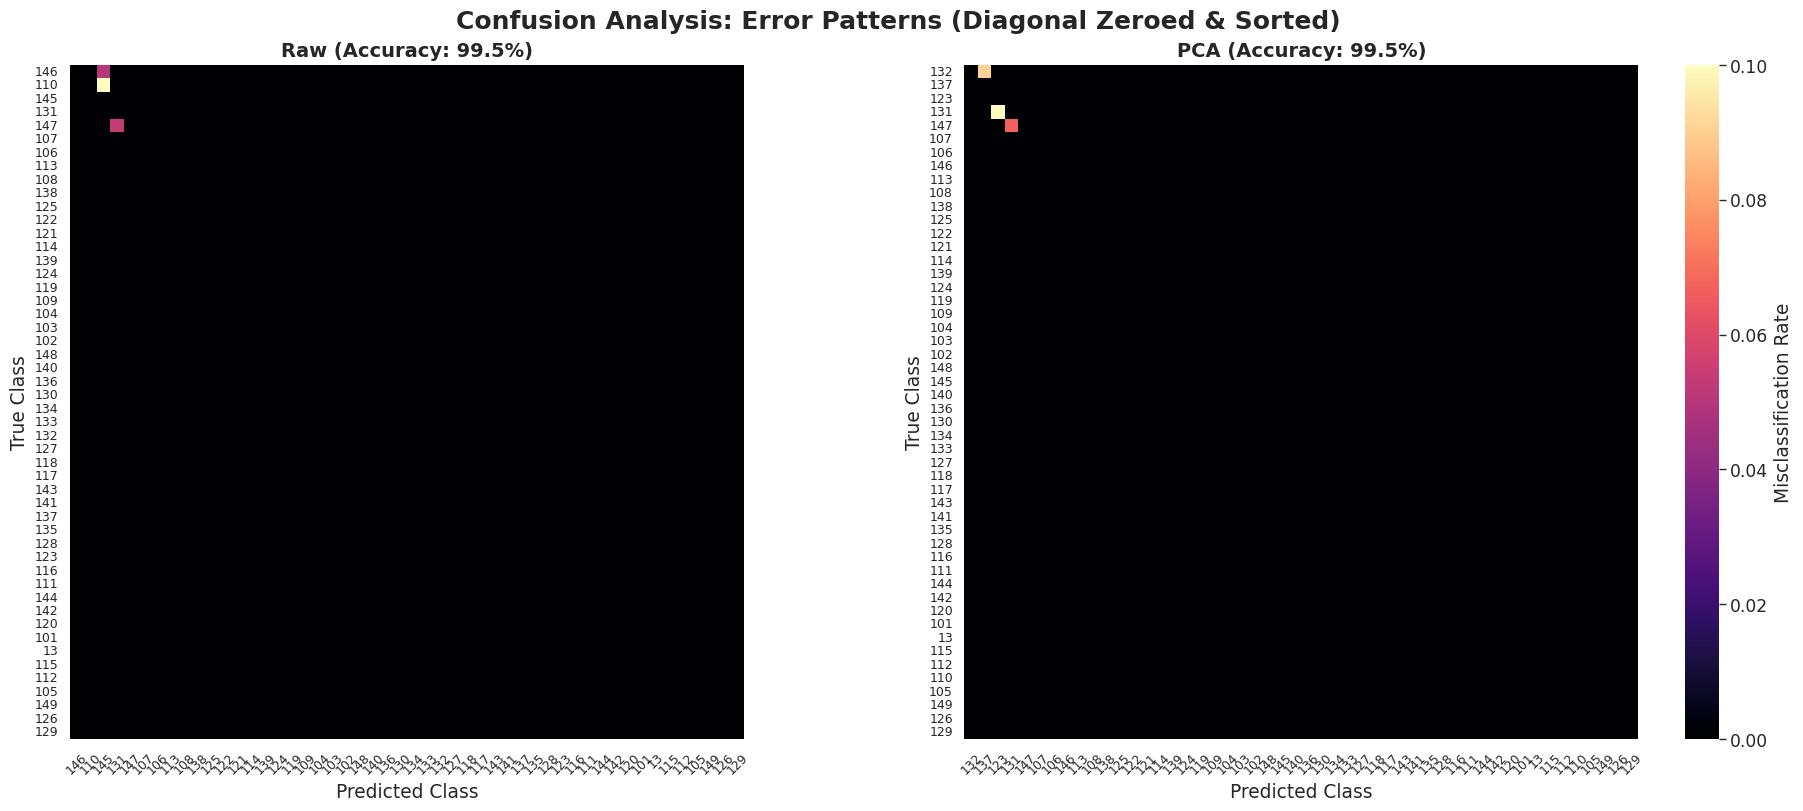

In [155]:
from sklearn.metrics import confusion_matrix
from scipy.cluster.hierarchy import linkage, leaves_list


sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

reg_results = results_df[results_df["Task"] == "Regression"]
targets = cond_names
methods = ["Raw", "PCA"]

fig, axes = plt.subplots(2, 5, figsize=(20, 8), constrained_layout=True)

for row_idx, method in enumerate(methods):
    for col_idx, target in enumerate(targets):
        ax = axes[row_idx, col_idx]

        res = reg_results[
            (reg_results["Target"] == target) & (reg_results["Method"] == method)
        ].iloc[0]
        model = res["Model"]
        # r2 = res["Metric 1 (MSE/Acc)"]
        r2 = res["Metric 2 (R2)"]

        target_idx = cond_names.index(target)
        y_true_train = y_cond_train[:, target_idx]
        y_true_test = y_cond_test[:, target_idx]

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        ax.scatter(
            y_true_train,
            y_pred_train,
            alpha=0.6,
            s=15,
            color="#d35400",
            label="Train",
            edgecolor="none",
            zorder=1,
        )
        ax.scatter(
            y_true_test,
            y_pred_test,
            alpha=0.6,
            s=20,
            color="#264653",
            label="Test",
            edgecolor="none",
            zorder=2,
        )

        combined_min = np.min([ax.get_xlim(), ax.get_ylim()])
        combined_max = np.max([ax.get_xlim(), ax.get_ylim()])
        lims = [combined_min, combined_max]

        ax.plot(lims, lims, "r--", linewidth=2, alpha=0.8, label="Ideal", zorder=3)

        if row_idx == 0:
            ax.set_title(f"{target}", fontsize=16, fontweight="bold")

        if col_idx == 0:
            ax.set_ylabel(f"{method}", fontsize=14, fontweight="bold")

        ax.text(
            0.05,
            0.9,
            f"$R^2={r2:.2f}$",
            transform=ax.transAxes,
            fontsize=12,
            fontweight="bold",
        )

        if row_idx == 0 and col_idx == 4:
            ax.legend(
                loc="lower right", frameon=True, framealpha=0.9, facecolor="white"
            )


class_results = results_df[results_df["Task"] == "Classification"]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)
fig.suptitle(
    "Confusion Analysis: Error Patterns (Diagonal Zeroed & Sorted)",
    fontsize=18,
    weight="bold",
)

for i, (idx, row) in enumerate(class_results.iterrows()):
    ax = axes[i]
    model = row["Model"]
    method = row["Method"]
    acc = row["Metric 1 (MSE/Acc)"]

    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_class_test, y_pred)

    cm_norm = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

    try:
        order = leaves_list(linkage(cm_norm, method="ward"))
    except:
        order = np.arange(len(cm))

    cm_sorted = cm_norm[order, :][:, order]
    classes = [le.classes_[k].replace("iteration_", "") for k in order]

    np.fill_diagonal(cm_sorted, 0)

    sns.heatmap(
        cm_sorted,
        annot=False,
        cmap="magma",
        xticklabels=classes,
        yticklabels=classes,
        ax=ax,
        square=True,
        cbar_kws={"label": "Misclassification Rate"} if i == 1 else None,
        cbar=(i == 1),
    )

    ax.set_title(f"{method} (Accuracy: {acc:.1%})", fontsize=14, weight="bold")
    ax.set_xlabel("Predicted Class")
    ax.set_ylabel("True Class")
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", labelsize=9)

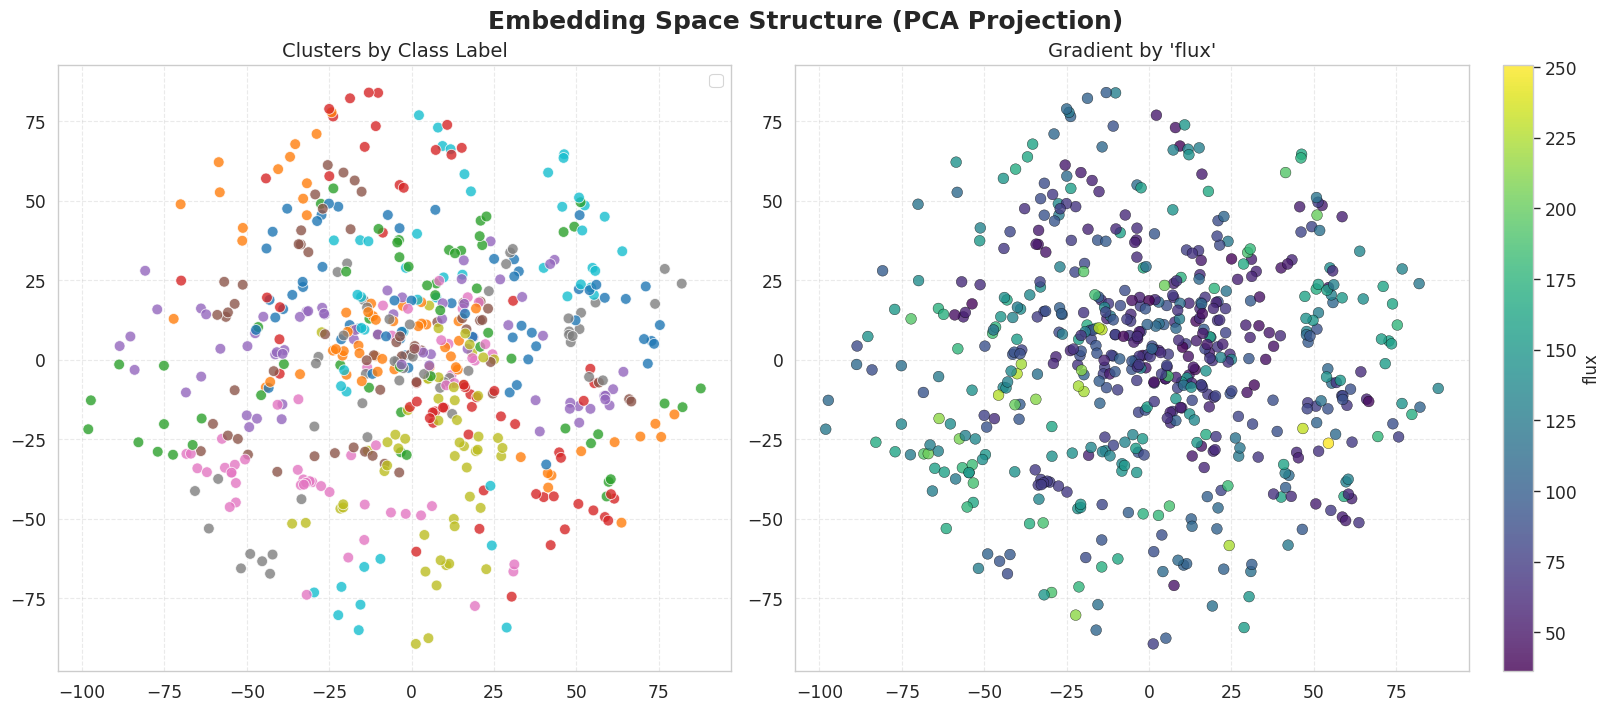

In [ ]:
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)
fig.suptitle("Embedding Space Structure (PCA Projection)", fontsize=18, weight="bold")

Trajectory = le.inverse_transform(y_class_test) if hasattr(le, "inverse_transform") else y_class_test

sns.scatterplot(
    x=X_vis[:,0], y=X_vis[:,1], 
    hue=Trajectory, 
    palette="tab10",  
    s=60, alpha=0.8, ax=axes[0]
)
axes[0].set_title("Clusters by Class Label", fontsize=14)
axes[0].legend([])
axes[0].grid(True, linestyle="--", alpha=0.4)

target_name = "flux" if "flux" in cond_names else cond_names[0]
target_idx = cond_names.index(target_name)
target_vals = y_cond_test[:, target_idx]

sc = axes[1].scatter(
    X_vis[:,0], X_vis[:,1], 
    c=target_vals, 
    cmap="viridis",  
    s=60, alpha=0.8, edgecolor="k", linewidth=0.3
)
axes[1].set_title(f"Gradient by "{target_name}"", fontsize=14)
axes[1].grid(True, linestyle="--", alpha=0.4)

cbar = plt.colorbar(sc, ax=axes[1])
cbar.set_label(target_name, fontsize=12)

plt.show()

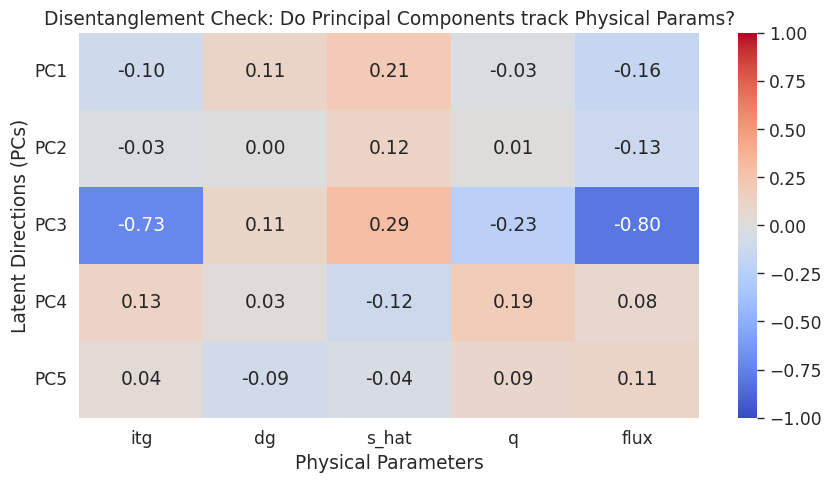

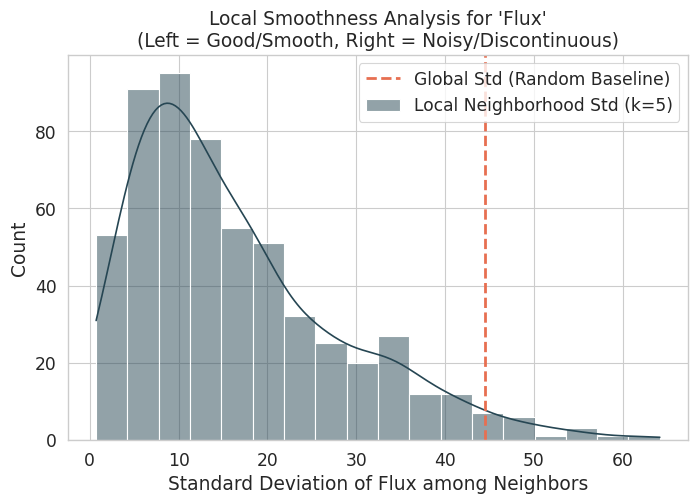

In [ ]:
from sklearn.neighbors import NearestNeighbors


pca_5 = PCA(n_components=5)
X_test_pca_5 = pca_5.fit_transform(X_test)

df_corr_analysis = pd.DataFrame(X_test_pca_5, columns=[f"PC{i+1}" for i in range(5)])

for i, name in enumerate(cond_names):
    df_corr_analysis[name] = y_cond_test[:, i]

corr_matrix = df_corr_analysis.corr()
pc_target_corr = corr_matrix.loc[[f"PC{i+1}" for i in range(5)], cond_names]

plt.figure(figsize=(10, 5))
sns.heatmap(pc_target_corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title("Disentanglement Check: Do Principal Components track Physical Params?")
plt.ylabel("Latent Directions (PCs)")
plt.xlabel("Physical Parameters")
plt.yticks(rotation=0)
plt.show()


k = 5
knn = NearestNeighbors(n_neighbors=k)
knn.fit(X_test)

distances, indices = knn.kneighbors(X_test)

target_idx = cond_names.index("flux") 
target_vals = y_cond_test[:, target_idx]

neighbor_vals = target_vals[indices]
local_std = np.std(neighbor_vals, axis=1)

global_std = np.std(target_vals)

plt.figure(figsize=(8, 5))
sns.histplot(local_std, kde=True, color="#264653", label=f"Local Neighborhood Std (k={k})")
plt.axvline(global_std, color="#e76f51", linestyle="--", linewidth=2, label=f"Global Std (Random Baseline)")
plt.title(f"Local Smoothness Analysis for "Flux"\n(Left = Good/Smooth, Right = Noisy/Discontinuous)")
plt.xlabel("Standard Deviation of Flux among Neighbors")
plt.legend()

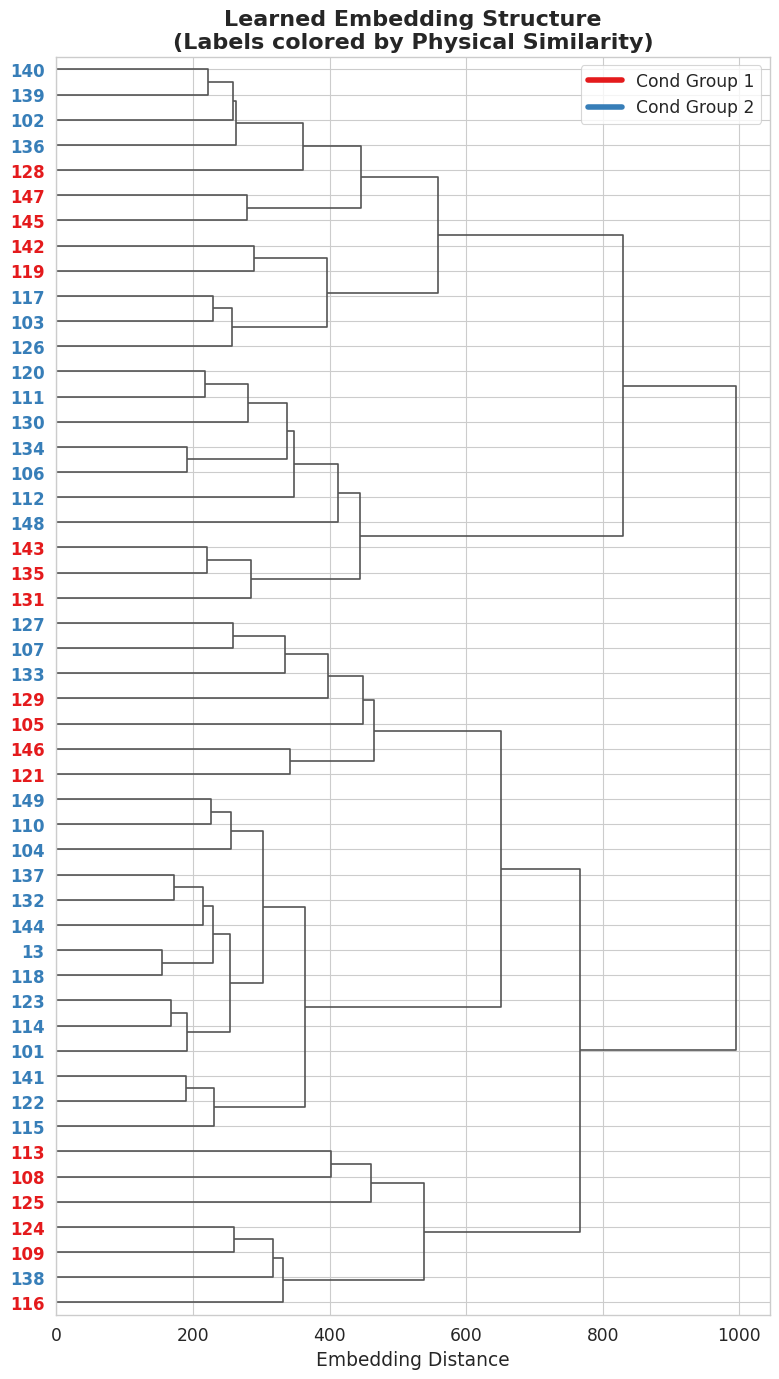

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy.cluster.hierarchy import dendrogram, linkage


unique_classes = np.unique(y_class_train)
phys_centroids = []
embed_centroids = []
labels_list = []

for cls in unique_classes:
    mask = y_class_train == cls
    phys_centroids.append(y_cond_train[mask].mean(axis=0))
    embed_centroids.append(X_train[mask].mean(axis=0))
    labels_list.append(le.inverse_transform([cls])[0].replace("iteration_", ""))

scaler = StandardScaler()
phys_data = scaler.fit_transform(phys_centroids)
embed_data = scaler.fit_transform(embed_centroids)

Z_phys = linkage(phys_data, method="ward")
phys_cluster_ids = fcluster(Z_phys, t=2, criterion="maxclust")

cmap = plt.get_cmap("Set1")
cluster_colors = {i: mcolors.to_hex(cmap(i - 1)) for i in np.unique(phys_cluster_ids)}

label_to_color = {
    lbl: cluster_colors[cid] for lbl, cid in zip(labels_list, phys_cluster_ids)
}

Z_embed = linkage(embed_data, method="ward")

plt.figure(figsize=(8, 14))

d = dendrogram(
    Z_embed,
    labels=labels_list,
    orientation="right",
    leaf_font_size=12,
    link_color_func=lambda k: "#555555",
)

ax = plt.gca()
y_labels = ax.get_ymajorticklabels()

for lbl in y_labels:
    text = lbl.get_text()
    color = label_to_color.get(text, "black")
    lbl.set_color(color)
    lbl.set_fontweight("bold")

legend_elements = [
    Line2D([0], [0], color=color, lw=4, label=f"Cond Group {cid}")
    for cid, color in cluster_colors.items()
]
ax.legend(handles=legend_elements, loc="upper right")

plt.title(
    "Learned Embedding Structure\n(Labels colored by Physical Similarity)",
    fontsize=16,
    weight="bold",
)
plt.xlabel("Embedding Distance")
plt.tight_layout()
plt.show()

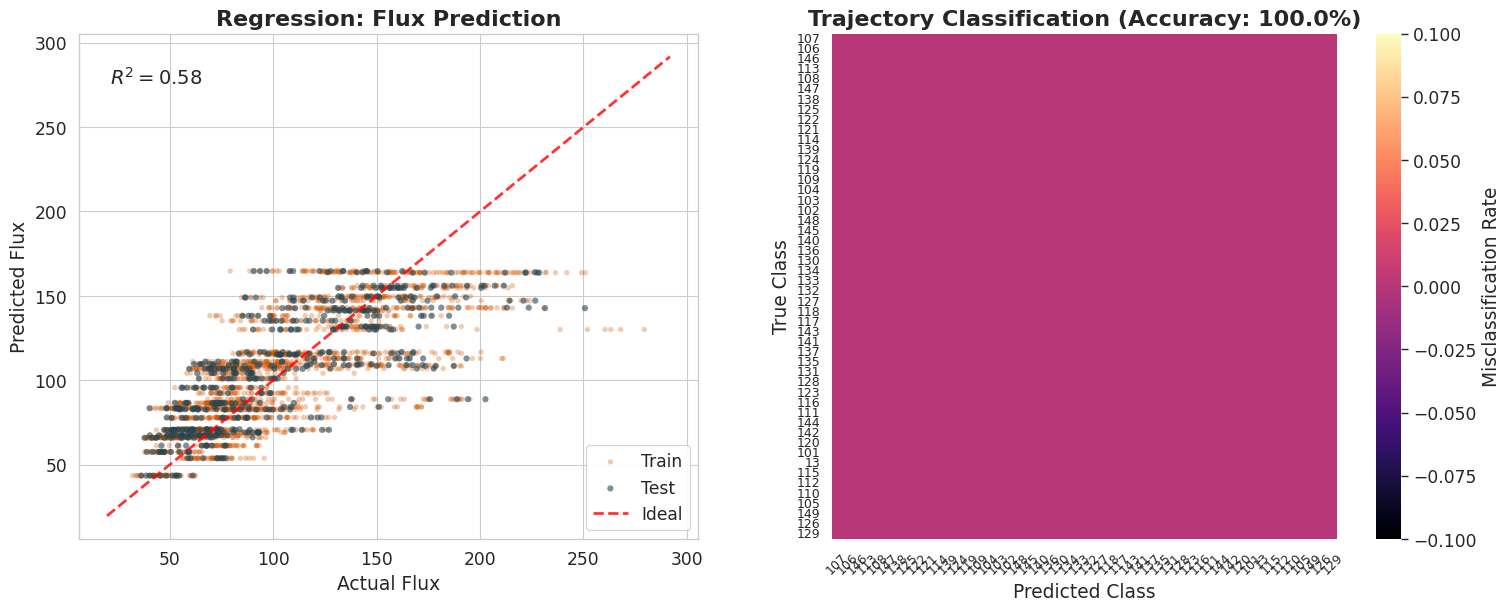

In [156]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import r2_score, accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from scipy.cluster.hierarchy import linkage, leaves_list


X_phys = conditions[:, :4]
y_flux = conditions[:, 4]

le = LabelEncoder()
y_traj_class = le.fit_transform(traj_names.ravel())

indices = np.arange(X_phys.shape[0])
X_train, X_test, idx_train, idx_test = train_test_split(
    X_phys, indices, test_size=0.2, random_state=42
)

y_reg_train = y_flux[idx_train]
y_reg_test = y_flux[idx_test]

y_cls_train = y_traj_class[idx_train]
y_cls_test = y_traj_class[idx_test]

reg_pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge(alpha=1.0))])
reg_pipe.fit(X_train, y_reg_train)
reg_preds_train = reg_pipe.predict(X_train)
reg_preds_test = reg_pipe.predict(X_test)
r2_score_val = r2_score(y_reg_test, reg_preds_test)

cls_pipe = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, C=1.0, solver="lbfgs")),
    ]
)
cls_pipe.fit(X_train, y_cls_train)
cls_preds_test = cls_pipe.predict(X_test)
acc_score_val = accuracy_score(y_cls_test, cls_preds_test)

sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.4)

fig, axes = plt.subplots(1, 2, figsize=(15, 6), constrained_layout=True)

ax = axes[0]

ax.scatter(
    y_reg_train,
    reg_preds_train,
    alpha=0.3,
    s=15,
    color="#d35400",
    label="Train",
    edgecolor="none",
    zorder=1,
)
ax.scatter(
    y_reg_test,
    reg_preds_test,
    alpha=0.6,
    s=20,
    color="#264653",
    label="Test",
    edgecolor="none",
    zorder=2,
)

lims = [np.min([ax.get_xlim(), ax.get_ylim()]), np.max([ax.get_xlim(), ax.get_ylim()])]
ax.plot(lims, lims, "r--", linewidth=2, alpha=0.8, label="Ideal", zorder=3)

ax.set_title("Regression: Flux Prediction", fontsize=16, fontweight="bold")
ax.set_xlabel("Actual Flux")
ax.set_ylabel("Predicted Flux")
ax.text(
    0.05,
    0.9,
    f"$R^2={r2_score_val:.2f}$",
    transform=ax.transAxes,
    fontsize=14,
    fontweight="bold",
)
ax.legend(loc="lower right", frameon=True, framealpha=0.9, facecolor="white")


ax = axes[1]

cm = confusion_matrix(y_cls_test, cls_preds_test)

cm_norm = cm.astype("float") / (cm.sum(axis=1)[:, np.newaxis] + 1e-10)

try:
    link_matrix = linkage(cm_norm, method="ward")
    order = leaves_list(link_matrix)
except:
    order = np.arange(len(cm))

cm_sorted = cm_norm[order, :][:, order]
classes_sorted = [le.classes_[k].replace("iteration_", "") for k in order]

np.fill_diagonal(cm_sorted, 0)

sns.heatmap(
    cm_sorted,
    annot=False,
    cmap="magma",
    xticklabels=classes_sorted,
    yticklabels=classes_sorted,
    ax=ax,
    square=True,
    cbar_kws={"label": "Misclassification Rate"},
)

ax.set_title(
    f"Trajectory Classification (Accuracy: {acc_score_val:.1%})",
    fontsize=16,
    fontweight="bold",
)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.tick_params(axis="x", rotation=45, labelsize=9)
ax.tick_params(axis="y", labelsize=9)